In [2]:
# ============================================================
# Forecasting Financial Inclusion in Ethiopia
# Task 1: Data Exploration and Enrichment
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
DATA_PATH = "../data/raw/"

In [10]:
# Cell 3 — Load the datasets with verified sheet names
data = pd.read_excel(
    DATA_PATH + "ethiopia_fi_unified_data.xlsx",
    sheet_name="ethiopia_fi_unified_data"
)

impact_links = pd.read_excel(
    DATA_PATH + "ethiopia_fi_unified_data.xlsx",
    sheet_name="Impact_sheet"
)

reference_codes = pd.read_excel(
    DATA_PATH + "reference_codes.xlsx"
)

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [11]:
print("Data Shape:")
print(data.shape)
print("\nImpact Links Shape:")
print(impact_links.shape)
print("\nReference Codes Shape:")
print(reference_codes.shape)

Data Shape:
(43, 34)

Impact Links Shape:
(14, 35)

Reference Codes Shape:
(71, 4)


In [12]:
print("--- Unified Data Sample ---")
display(data.head())
print("\n--- Impact Links Sample ---")
display(impact_links.head())
print("\n--- Reference Codes Sample ---")
display(reference_codes.head())

--- Unified Data Sample ---


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,%,2014-12-31,NaT,NaT,2014,all,national,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,%,2017-12-31,NaT,NaT,2017,all,national,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,all,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,male,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,female,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN



--- Impact Links Sample ---


,record_id,parent_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,percentage,%,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,ACC_OWNERSHIP,direct,increase,high,15.0,12,literature,Kenya,Example_Trainee,2025-01-20,NaN,Kenya M-Pesa showed +20pp over 5 years
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,count,users,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,high,USG_TELEBIRR_USERS,direct,increase,high,NaN,3,empirical,NaN,Example_Trainee,2025-01-20,NaN,Direct subscriber acquisition
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,percentage,%,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,USG_P2P_COUNT,direct,increase,high,25.0,6,empirical,NaN,Example_Trainee,2025-01-20,NaN,New digital payment channel
3,IMP_0004,EVT_0002,impact_link,NaN,ACCESS,Safaricom effect on 4G Coverage,NaN,NaN,15.0,NaN,percentage,%,2022-08-01,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,ACC_4G_COV,direct,increase,medium,15.0,12,empirical,NaN,Example_Trainee,2025-01-20,NaN,Network investment from competition
4,IMP_0005,EVT_0002,impact_link,NaN,AFFORDABILITY,Safaricom effect on Data Affordability,NaN,NaN,-20.0,NaN,percentage,%,2022-08-01,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,AFF_DATA_INCOME,indirect,decrease,medium,-20.0,12,literature,Rwanda,Example_Trainee,2025-01-20,NaN,Competition typically reduces prices



--- Reference Codes Sample ---


,field,code,description,applies_to
0,record_type,observation,Actual measured value from a source,All
1,record_type,event,Policy launch market event or milestone,All
2,record_type,impact_link,Relationship between event and indicator (link...,All
3,record_type,target,Policy target or official goal,All
4,record_type,baseline,Starting point for comparison,All


In [13]:
print("Data Columns:")
print(data.columns.tolist())
print("\nImpact Link Columns:")
print(impact_links.columns.tolist())
print("\nReference Code Columns:")
print(reference_codes.columns.tolist())

Data Columns:
['record_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes']

Impact Link Columns:
['record_id', 'parent_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_mon

In [14]:
print("--- Count by Record Type ---")
print(data['record_type'].value_counts())

print("\n--- Summary Statistics for Numeric Fields ---")
display(data.describe(include=[np.number]))

--- Count by Record Type ---
record_type
observation    30
event          10
target          3
Name: count, dtype: int64

--- Summary Statistics for Numeric Fields ---


,value_numeric,region,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,notes
count,3.300000e+01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,9.437258e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,4.231061e+11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.080000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,2.400000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,6.140000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.500000e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,2.380000e+12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
# Cell 8 — Temporal Coverage Analysis (Updated for observation_date)
data['observation_date'] = pd.to_datetime(data['observation_date'], errors='coerce')

for rtype in data['record_type'].unique():
    subset = data[data['record_type'] == rtype]
    print(f"Record Type: {rtype}")
    print(f"  Start Date: {subset['observation_date'].min()}")
    print(f"  End Date:   {subset['observation_date'].max()}")
    print(f"  Total Rows: {len(subset)}\n")

Record Type: observation
  Start Date: 2014-12-31 00:00:00
  End Date:   2025-12-31 00:00:00
  Total Rows: 30

Record Type: target
  Start Date: 2025-12-31 00:00:00
  End Date:   2030-12-31 00:00:00
  Total Rows: 3

Record Type: event
  Start Date: 2021-05-17 00:00:00
  End Date:   2025-12-18 00:00:00
  Total Rows: 10



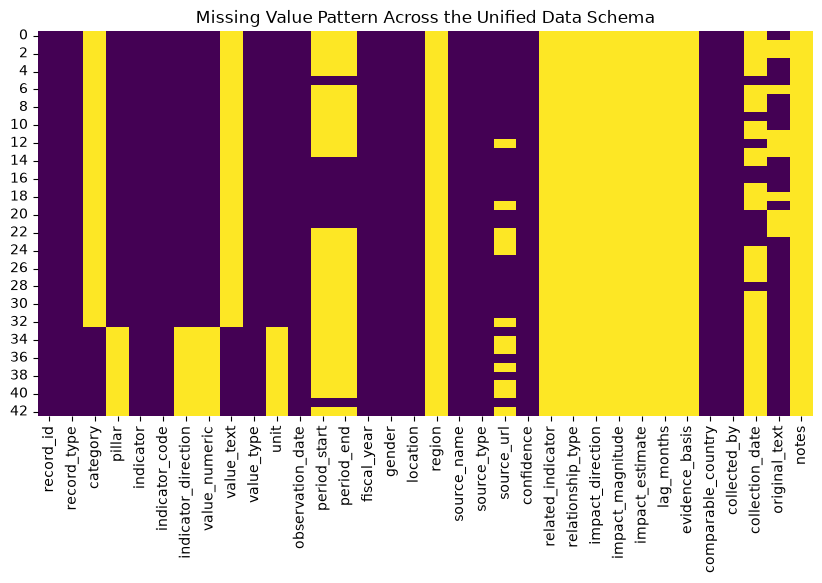

Missing values count per column:
record_id               0
record_type             0
category               33
pillar                 10
indicator               0
indicator_code          0
indicator_direction    10
value_numeric          10
value_text             33
value_type              0
unit                   10
observation_date        0
period_start           33
period_end             33
fiscal_year             0
gender                  0
location                0
region                 43
source_name             0
source_type             0
source_url             12
confidence              0
related_indicator      43
relationship_type      43
impact_direction       43
impact_magnitude       43
impact_estimate        43
lag_months             43
evidence_basis         43
comparable_country      0
collected_by            0
collection_date        33
original_text          10
notes                  43
dtype: int64


In [19]:
plt.figure(figsize=(10, 5))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Value Pattern Across the Unified Data Schema")
plt.show()

print("Missing values count per column:")
print(data.isnull().sum())

In [20]:
observations_df = data[data['record_type'] == 'observation'].copy()
events_df = data[data['record_type'] == 'event'].copy()
targets_df = data[data['record_type'] == 'target'].copy()

print("Pipeline structures successfully decoupled and ready for modeling!")

Pipeline structures successfully decoupled and ready for modeling!
